# 03 — Temporal Analysis & Leakage

**Owner:** Bimsara's lane — timestamp/cycle analysis, event-window leakage study, split strategy.

**Purpose:** decide which features are safe to use and how to split the data. This is the notebook Eval 1 turns on: it shows why same-row speed is leakage, checks whether the current gives an early signal (and whether that signal survives a fair control), and fixes the train/test split every later notebook reuses.

**Output:** `data/processed/eligible_features.json` (the 14 raw leakage-safe features; notebook 04 adds two engineered ones and re-saves the final list), `data/processed/split_cycles.json`, and figures `fig03_stop_timeline.png`, `fig03_event_window.png`.

**Viva questions to be ready for:** What is leakage here and how did you prevent it? Why a group/time split, not a random one?

Every important choice has a decision-log cell (what we decided, the evidence, the alternative considered, why it was rejected).

In [1]:
import sys
from pathlib import Path

# Jupyter's kernel CWD is notebooks/, so add the repo root to sys.path
# before importing anything from src/.
sys.path.append(str(Path.cwd().parent))

In [2]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import RANDOM_STATE, FIGURES_DIR, PROCESSED_DATA_DIR
from src.pipeline import load_data

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [3]:
df = load_data()
df = df.sort_values("Timestamp").reset_index(drop=True)
df.shape

(7409, 24)

## Cycle stats

Rows per cycle, reading cadence and the recording gap: 240 cycles of 11–102 rows (median 25), about one reading per second, and one long gap (about 5 h 14 min) between the morning and afternoon recordings on 26 Oct 2022.

In [4]:
df.groupby("cycle").size().describe()

count    240.000000
mean      30.870833
std       12.902433
min       11.000000
25%       24.000000
50%       25.000000
75%       30.000000
max      102.000000
dtype: float64

In [5]:
# Reading cadence (~1 s between rows) and the one large gap (the maximum)
df["Timestamp"].diff().describe()

count                         7408
mean     0 days 00:00:03.553554670
std      0 days 00:03:38.580161805
min         0 days 00:00:00.984000
25%         0 days 00:00:01.003000
50%         0 days 00:00:01.005000
75%         0 days 00:00:01.007000
max         0 days 05:13:34.125000
Name: Timestamp, dtype: object

## Stop episodes

A stop episode is a run of consecutive `Robot_ProtectiveStop == 1` rows. The 278 stop rows form 108 episodes (median 2 rows, max 12), spread over 78 of the 240 cycles.

In [6]:
is_stop = df["Robot_ProtectiveStop"] == 1
episode_id = (is_stop != is_stop.shift()).cumsum()
episodes = df[is_stop].groupby(episode_id[is_stop]).size()
print("stop rows:", is_stop.sum())
print("episodes:", episodes.shape[0])
print("cycles containing a stop:", df.loc[is_stop, "cycle"].nunique(), "of", df["cycle"].nunique())
episodes.describe()

stop rows: 278
episodes: 108
cycles containing a stop: 78 of 240


count    108.000000
mean       2.574074
std        1.880563
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max       12.000000
dtype: float64

## Timeline of stops

When do stops happen across the day? Saved to `fig03_stop_timeline.png`.

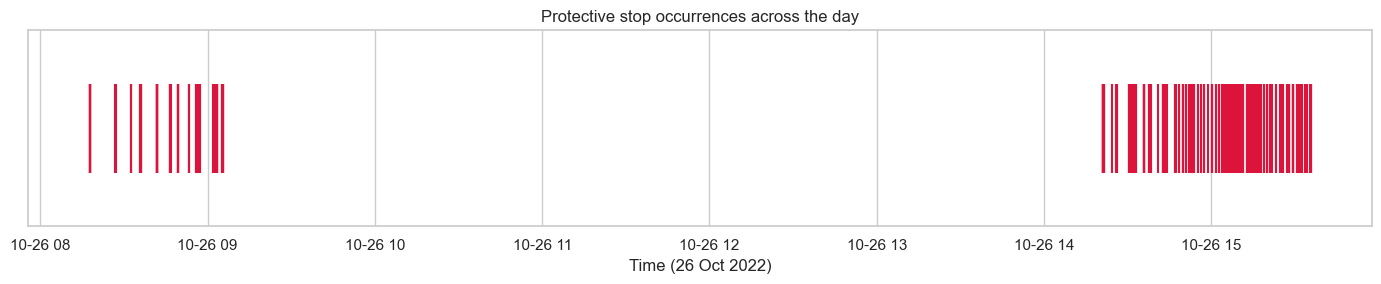

In [7]:
fig, ax = plt.subplots(figsize=(14, 3))
stop_times = df.loc[df["Robot_ProtectiveStop"] == 1, "Timestamp"]
ax.eventplot(stop_times, lineoffsets=0, linelengths=0.8, color="crimson")
ax.set_yticks([])
ax.set_xlabel("Time (26 Oct 2022)")
ax.set_title("Protective stop occurrences across the day")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig03_stop_timeline.png", dpi=150, bbox_inches="tight")
plt.show()


## Event-window leakage study (±10 rows around each stop)

For each stop episode, look at the total joint speed and total joint current from 10 rows before to 10 rows after its first stop row. Headline: the median total joint speed is about 0.002 at stop rows against 0.056 at normal rows, so same-row speed describes a robot that has *already* stopped rather than one about to stop. The class-median table also lets us check whether any other sensor column carries the same kind of same-row information.

In [8]:
speed_cols = [c for c in df.columns if c.startswith("Speed_J")]
# Total joint speed = sum of the absolute joint speeds: a simple, sign-free measure of overall motion
df["total_joint_speed"] = df[speed_cols].abs().sum(axis=1)
df.groupby("Robot_ProtectiveStop")["total_joint_speed"].median()

Robot_ProtectiveStop
0.0    0.056224
1.0    0.002019
Name: total_joint_speed, dtype: float64

In [9]:
sensor_cols = [c for c in df.columns if c.startswith(("Current_", "Temperature_", "Tool_current"))]
df.groupby("Robot_ProtectiveStop")[sensor_cols].median().T

Robot_ProtectiveStop,0.0,1.0
Current_J0,-0.083452,-0.020977
Temperature_T0,36.500000,36.937500
Current_J1,-2.221180,-2.822194
Temperature_J1,39.687500,39.937500
Current_J2,-1.060021,-1.613609
Temperature_J2,40.187500,40.312500
Current_J3,-0.562035,-0.993316
Temperature_J3,43.062500,43.125000
Current_J4,-0.014018,0.018759
Temperature_J4,45.062500,45.125000


In [10]:
current_cols = [c for c in df.columns if c.startswith("Current_")]
df["total_joint_current"] = df[current_cols].abs().sum(axis=1)
df.groupby("Robot_ProtectiveStop")["total_joint_current"].median()

Robot_ProtectiveStop
0.0    4.305680
1.0    5.989461
Name: total_joint_current, dtype: float64

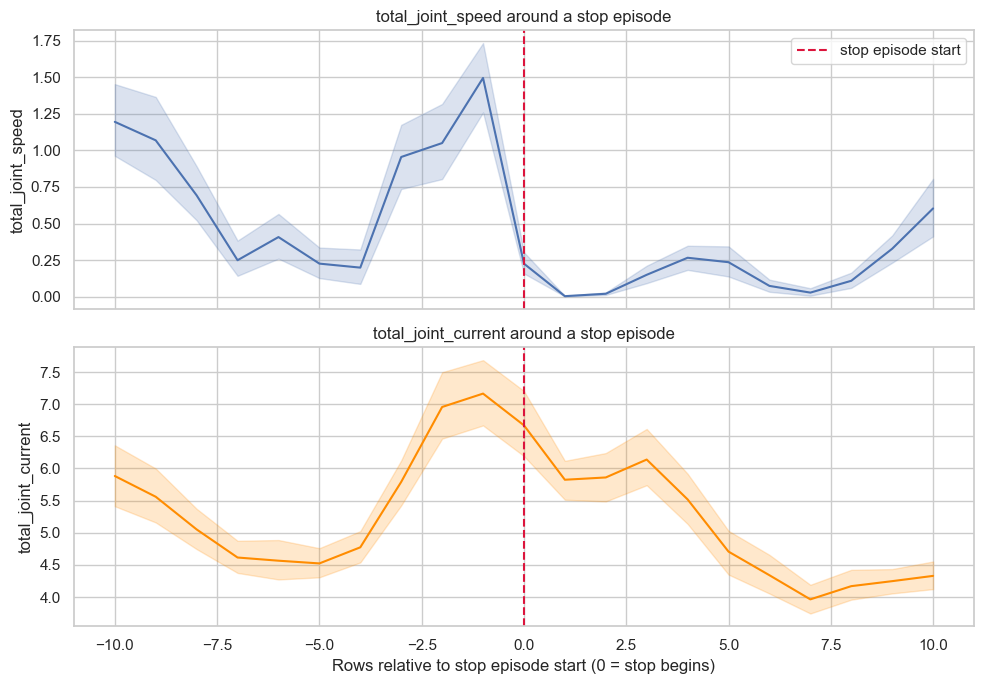

In [11]:
# Windows of ±10 rows around the first row of each stop episode (row index = time order)

window = 10
episode_starts = df[is_stop].groupby(episode_id[is_stop]).apply(lambda g: g.index[0])

records = []
for ep_start in episode_starts:
    lo, hi = max(ep_start - window, 0), min(ep_start + window, len(df) - 1)
    for idx in range(lo, hi + 1):
        records.append({
            "relative_row": idx - ep_start,
            "total_joint_speed": df.loc[idx, "total_joint_speed"],
            "total_joint_current": df.loc[idx, "total_joint_current"],
        })

window_df = pd.DataFrame(records)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
sns.lineplot(data=window_df, x="relative_row", y="total_joint_speed", ax=axes[0])
axes[0].axvline(0, color="crimson", linestyle="--", label="stop episode start")
axes[0].set_title("total_joint_speed around a stop episode")
axes[0].legend()

sns.lineplot(data=window_df, x="relative_row", y="total_joint_current", ax=axes[1], color="darkorange")
axes[1].axvline(0, color="crimson", linestyle="--")
axes[1].set_title("total_joint_current around a stop episode")
axes[1].set_xlabel("Rows relative to stop episode start (0 = stop begins)")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig03_event_window.png", dpi=150, bbox_inches="tight")
plt.show()


### Control: is the rise before a stop just the start of the cycle?

Stops tend to begin early in a cycle, and every cycle starts with a burst of current, so a rise "before a stop" could simply be the normal start of a cycle. This check (1) shows where in its cycle each stop begins, (2) shows the average total current of *normal* rows by position in the cycle, and (3) compares the rows just before each stop with normal rows at the same cycle position. It uses no model.

In [12]:
# Position of each reading inside its cycle (0 = first row of the cycle)
df["cycle_pos"] = df.groupby("cycle").cumcount()
onset_pos = df.loc[episode_starts.values, "cycle_pos"]
print(f"First stop row of each episode sits at cycle position: median {onset_pos.median():.0f}; "
      f"{(onset_pos < 6).sum()} of {len(onset_pos)} episodes start within the first 6 rows of a cycle.")

normal = df[df["Robot_ProtectiveStop"] == 0]
by_pos = normal.groupby("cycle_pos")["total_joint_current"].mean()
print("\nMean total_joint_current of normal rows by cycle position (0-12):")
print(by_pos.iloc[:13].round(2).to_string())
print(f"Mean at cycle positions >= 13: {normal.loc[normal['cycle_pos'] >= 13, 'total_joint_current'].mean():.2f}")

cyc = df["cycle"].to_numpy()
tjc = df["total_joint_current"].to_numpy()
pos = df["cycle_pos"].to_numpy()
same_cycle = {r: np.mean([cyc[s + r] == cyc[s] for s in episode_starts if s + r >= 0]) for r in (-5, -4, -3, -2, -1)}
print("\nShare of episodes whose row r (relative to the first stop row) lies in the same cycle:",
      {r: round(v, 2) for r, v in same_cycle.items()})

# Rows k before a stop starts (same cycle, not themselves stop rows) vs normal rows at the same cycle position
rows = {}
for k in (5, 4, 3, 2, 1):
    idx = [s - k for s in episode_starts if s - k >= 0 and cyc[s - k] == cyc[s] and not is_stop.iloc[s - k]]
    control = np.concatenate([normal.loc[normal["cycle_pos"] == pos[i], "total_joint_current"].to_numpy() for i in idx])
    rows[f"{k} row(s) before a stop"] = {"episodes": len(idx), "before a stop": tjc[idx].mean(),
                                         "normal rows, same cycle position": control.mean()}
comparison = pd.DataFrame(rows).T
comparison["difference"] = comparison["before a stop"] - comparison["normal rows, same cycle position"]
comparison.round(2)

First stop row of each episode sits at cycle position: median 5; 69 of 108 episodes start within the first 6 rows of a cycle.

Mean total_joint_current of normal rows by cycle position (0-12):
cycle_pos
0     4.28
1     5.69
2     8.11
3     8.39
4     6.28
5     4.58
6     4.35
7     4.33
8     4.81
9     4.74
10    5.04
11    4.50
12    4.83
Mean at cycle positions >= 13: 4.67

Share of episodes whose row r (relative to the first stop row) lies in the same cycle: {-5: 0.51, -4: 0.69, -3: 0.99, -2: 1.0, -1: 1.0}


,episodes,before a stop,"normal rows, same cycle position",difference
5 row(s) before a stop,47.0,4.45,4.75,-0.31
4 row(s) before a stop,69.0,5.08,5.10,-0.01
3 row(s) before a stop,102.0,5.83,5.69,0.14
2 row(s) before a stop,104.0,6.97,6.53,0.44
1 row(s) before a stop,108.0,7.17,6.79,0.37


## grip_lost cross-tab

Overlap between `grip_lost` and `Robot_ProtectiveStop`: only 3 of the 243 grip-loss rows are stop rows, so grip loss is a separate event and weak as a predictor, not a leakage source.

In [13]:
pd.crosstab(df["grip_lost"], df["Robot_ProtectiveStop"])

Robot_ProtectiveStop,0.0,1.0
grip_lost,,
False,6837,275
True,240,3


## Final eligible-feature list

The leakage study excludes the six `Speed_J*` columns (same-row leakage). The remaining 14 raw features (6 currents, 6 temperatures, `Tool_current`, `grip_lost`) are saved to `eligible_features.json`. Notebook 04 adds two engineered current features and re-saves the final 16-feature list to the same file; notebook 07 later narrows the deployed model to 9 features.

In [14]:
ELIGIBLE_FEATURES = [
    "Current_J0", "Current_J1", "Current_J2", "Current_J3", "Current_J4", "Current_J5",
    "Temperature_T0", "Temperature_J1", "Temperature_J2", "Temperature_J3", "Temperature_J4", "Temperature_J5",
    "Tool_current",
    "grip_lost",
]


with open(PROCESSED_DATA_DIR / "eligible_features.json", "w") as f:
    json.dump(ELIGIBLE_FEATURES, f, indent=2)

ELIGIBLE_FEATURES

['Current_J0',
 'Current_J1',
 'Current_J2',
 'Current_J3',
 'Current_J4',
 'Current_J5',
 'Temperature_T0',
 'Temperature_J1',
 'Temperature_J2',
 'Temperature_J3',
 'Temperature_J4',
 'Temperature_J5',
 'Tool_current',
 'grip_lost']

## Split strategy decision

Chronological split by cycle: order the cycles by start time and hold out the last 20% as the test set, so that no cycle is shared between train and test and the test set is later in time. The cycle assignment is saved to `data/processed/split_cycles.json` so that notebook 04 and every model notebook reuse exactly the same split.

In [15]:
# Order cycles by when they started
cycle_start = df.groupby("cycle")["Timestamp"].min().sort_values()

# Last ~20% of cycles (by time) become the test holdout
n_test_cycles = round(len(cycle_start) * 0.2)
test_cycles = cycle_start.iloc[-n_test_cycles:].index.tolist()
train_cycles = cycle_start.iloc[:-n_test_cycles].index.tolist()

train_df = df[df["cycle"].isin(train_cycles)].reset_index(drop=True)
test_df = df[df["cycle"].isin(test_cycles)].reset_index(drop=True)

print("train cycles:", len(train_cycles), "| train rows:", len(train_df))
print("test cycles:", len(test_cycles), "| test rows:", len(test_df))
print("train stop rate:", train_df["Robot_ProtectiveStop"].mean())
print("test stop rate:", test_df["Robot_ProtectiveStop"].mean())

# Save the split so notebook 04 (and everyone downstream) reuses the exact same cycles
split_info = {
    "strategy": "chronological_by_cycle_last_20pct_holdout",
    "train_cycles": train_cycles,
    "test_cycles": test_cycles,
}
with open(PROCESSED_DATA_DIR / "split_cycles.json", "w") as f:
    json.dump(split_info, f, indent=2)


train cycles: 192 | train rows: 5494
test cycles: 48 | test rows: 1915
train stop rate: 0.03108997805413314
test stop rate: 0.057233704292527825


## Decision log

### Decision: Exclude Speed_J0-J5 from the eligible-feature list; keep Current, Temperature, Tool_current, grip_lost
- **Evidence:** Median total_joint_speed is 0.056 at normal rows vs 0.002 at stop rows — a stopped robot has ~zero speed by definition, so same-row speed describes the outcome, not a cause. Median total_joint_current is *higher* at stop rows (5.99 vs 4.31) — a real difference in the data (motors working harder), not a tautology. Temperature and Tool_current show no meaningful difference between classes. grip_lost overlaps a stop on only 3/243 rows, so it is leakage-safe but weak. Speed is also not a clean separator (45.6% of normal rows have near-zero total speed, notebook 02), so excluding it costs little: the reason is causal direction, not performance.
- **Alternative considered:** Keep Speed_J0-J5 as features.
- **Why rejected:** Speed reads ~0 at stop rows because "stopped" means "not moving": using it would let the model detect the outcome rather than anything that leads to it, and it would not help predict a stop before it happens.
- **Later narrowing:** notebook 07 drops the six temperatures and `grip_lost` from the deployed model (no importance, and the temperatures act as a clock), leaving 9 features.

### Decision: Chronological-by-cycle split (last 20% of cycles as test), StratifiedGroupKFold by cycle for CV within training
- **Evidence:** Ordering the 240 cycles by start time and holding out the last 48 (20%) gives 192 train cycles and 48 test cycles. The split is made on the 7,409 raw rows (5,494 train, 1,915 test); notebook 04 then drops the 54 unlabelled rows, leaving 5,468 train rows (170 stop rows, 3.11%) and 1,887 test rows (108 stop rows in 51 episodes, 5.72%). The test set has enough positives to evaluate on, but its stop rate is higher than train's (5.72% vs 3.11%; 3.78% overall), so test PR-AUC is not directly comparable with train.
- **Alternative considered:** Pure StratifiedGroupKFold by cycle (random group assignment, ignoring time order); naive row-level chronological split.
- **Why rejected:** Random group assignment does not test whether the model generalizes to situations that happen *later* in time, which is the realistic deployment scenario. A row-level chronological split can cut a single cycle across train and test, reintroducing cycle-level leakage. Inside the training set, cross-validation still uses StratifiedGroupKFold by cycle (whole cycles held out); notebook 07 adds a time-forward check.

### Observation (revised after a same-cycle-position control): the rise in total_joint_current before a stop is mostly the start-of-cycle wave
- **What the plot shows:** the ±10-row event-window plot has total_joint_current climbing from ~4.5 to ~7 between rows −5 and −1 before a stop starts, then falling; speed drops only after onset.
- **What the control shows:** stops start early in the cycle (median position 5; 69 of the 108 episodes within the first 6 rows), and every cycle has the same burst of current in its first rows (mean 8.1–8.4 at positions 2–3 against about 4.7 later in the cycle). Against normal rows at the same cycle position, the rows just before a stop are only about +0.4 above at 1–2 rows before (7.17 vs 6.79, 6.97 vs 6.53) and no different at 3–5 rows. The plot also aligns by row index, so rows −5/−4 fall in the previous cycle for many episodes.
- **Conclusion:** the pre-stop rise is largely the normal start of a cycle, not a precursor specific to stops. The first version of this entry called it "a candidate early-warning signal"; that is not supported. An early-warning target was tested separately (notebook 07, section 10): statistically above chance, but not practical.
- **Not decided here:** the detection-vs-early-warning framing remains a team decision (29 Sep).